In [ ]:
# instalaciones

%pip install -q ucimlrepo

In [ ]:
# Imports

from ucimlrepo import fetch_ucirepo      # Libreria para interactuar con el repositorio UCI Machine Learning
import pandas as pd                      # Librería para manipulación y análisis de datos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px              # Librería para crear gráficos interactivos y visualizaciones

In [ ]:
# fetch dataset
beijing_pm2_5 = fetch_ucirepo(id=381)

# data (como pandas dataframes)
X = beijing_pm2_5.data.features
y = beijing_pm2_5.data.targets
df = pd.concat([X, y], axis=1)

print(beijing_pm2_5.variables)
print("-------------------------------------------------------------")

     name     role         type demographic description units missing_values
0      No       ID      Integer        None        None  None             no
1    year  Feature      Integer        None        None  None             no
2   month  Feature      Integer        None        None  None             no
3     day  Feature      Integer        None        None  None             no
4    hour  Feature      Integer        None        None  None             no
5   pm2.5   Target      Integer        None        None  None            yes
6    DEWP  Feature      Integer        None        None  None             no
7    TEMP  Feature      Integer        None        None  None             no
8    PRES  Feature      Integer        None        None  None             no
9    cbwd  Feature  Categorical        None        None  None             no
10    Iws  Feature   Continuous        None        None  None             no
11     Is  Feature      Integer        None        None  None             no

In [ ]:
# Crear df_dates uniendo las columnas de año, mes, día y hora
df_dates = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
print("df_dates creado:")
display(df_dates.head())

df_dates creado:


,0
0,2010-01-01 00:00:00
1,2010-01-01 01:00:00
2,2010-01-01 02:00:00
3,2010-01-01 03:00:00
4,2010-01-01 04:00:00


### Preparación de datos para series de tiempo y visualización de autocorrelación

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Asignar df_dates como el índice del DataFrame
df_ts = df.copy()
df_ts['date'] = df_dates
df_ts = df_ts.set_index('date')

# Seleccionar la serie pm2.5 y eliminar los valores nulos para el análisis de autocorrelación
pm25_series = df_ts['pm2.5'].dropna()

print("Serie pm2.5 preparada para análisis de series de tiempo (primeras 5 filas):")
display(pm25_series.head())

Serie pm2.5 preparada para análisis de series de tiempo (primeras 5 filas):


,pm2.5
date,
2010-01-02 00:00:00,129.0
2010-01-02 01:00:00,148.0
2010-01-02 02:00:00,159.0
2010-01-02 03:00:00,181.0
2010-01-02 04:00:00,138.0


### Gráfico de Autocorrelación (ACF)


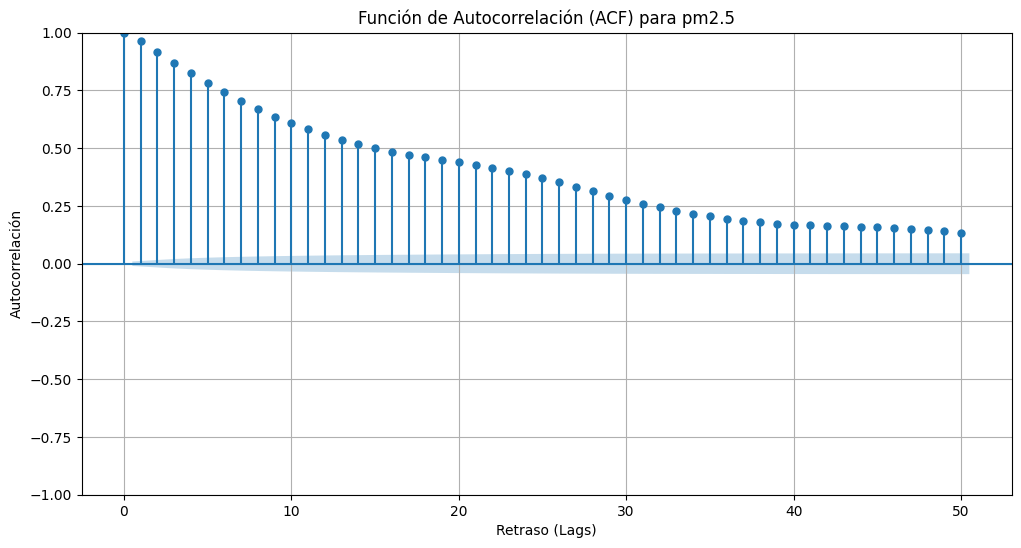

In [ ]:
fig_acf = plt.figure(figsize=(12, 6))
plot_acf(pm25_series, lags=50, ax=plt.gca())
plt.title('Función de Autocorrelación (ACF) para pm2.5')
plt.xlabel('Retraso (Lags)')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.show()



### Gráfico de Autocorrelación Parcial (PACF)

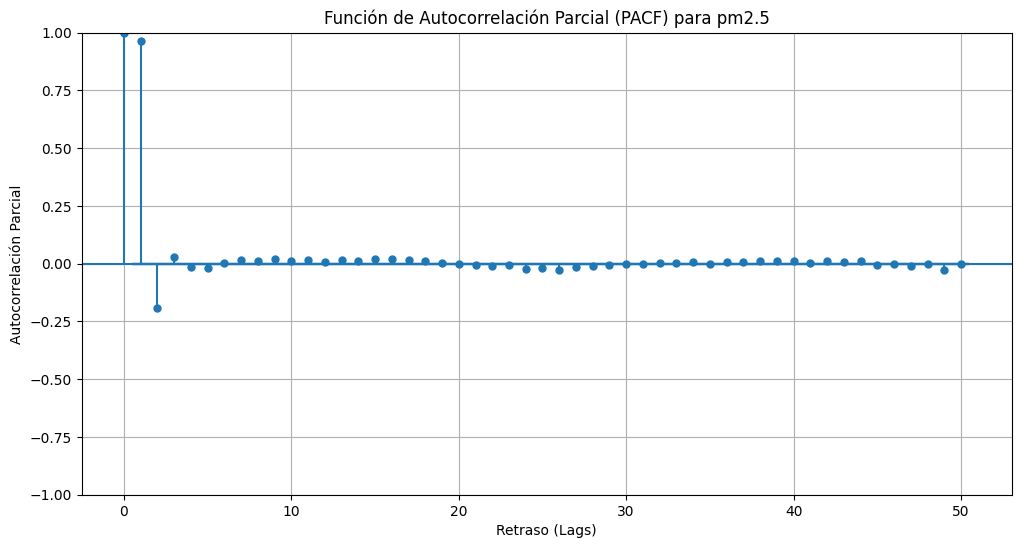

In [ ]:
fig_pacf = plt.figure(figsize=(12, 6))
plot_pacf(pm25_series, lags=50, ax=plt.gca())
plt.title('Función de Autocorrelación Parcial (PACF) para pm2.5')
plt.xlabel('Retraso (Lags)')
plt.ylabel('Autocorrelación Parcial')
plt.grid(True)
plt.show()

### Identificar Lags con Alta Correlación en ACF

In [ ]:
from statsmodels.tsa.stattools import acf

def get_high_correlation_lags(series, nlags=50, threshold=0.5):
    """
    Calcula la Función de Autocorrelación (ACF) y devuelve los lags
    cuyos valores de autocorrelación (en valor absoluto) superan un umbral dado.

    Args:
        series (pd.Series): La serie de tiempo para la cual calcular la ACF.
        nlags (int): El número de lags a considerar.
        threshold (float): El umbral para la autocorrelación (en valor absoluto).

    Returns:
        pd.DataFrame: Un DataFrame con los lags y sus valores de autocorrelación
                      que superan el umbral.
    """
    # Calcula la ACF. El argumento 'unbiased' para la estimación es a menudo preferido.
    acf_values = acf(series, nlags=nlags, fft=True)

    # Crea un DataFrame para facilitar el filtrado y la visualización
    acf_df = pd.DataFrame({'lag': range(len(acf_values)), 'autocorrelation': acf_values})

    # Filtra los lags donde el valor absoluto de la autocorrelación supera el umbral
    high_corr_lags = acf_df[abs(acf_df['autocorrelation']) > threshold]

    return high_corr_lags

# Define el umbral deseado
umbral_correlacion = 0.70 # Puedes ajustar este valor según tus necesidades

# Obtiene los lags con alta correlación
lags_significativos = get_high_correlation_lags(pm25_series, threshold=umbral_correlacion)

print(f"Lags con autocorrelación (en valor absoluto) mayor a {umbral_correlacion}:")
display(lags_significativos)


Lags con autocorrelación (en valor absoluto) mayor a 0.7:


,lag,autocorrelation
0,0,1.000000
1,1,0.964496
2,2,0.916849
3,3,0.870984
4,4,0.826790
5,5,0.783374
6,6,0.741842
7,7,0.703524


### Visualización del Ciclo Diurno para una Variable Seleccionada

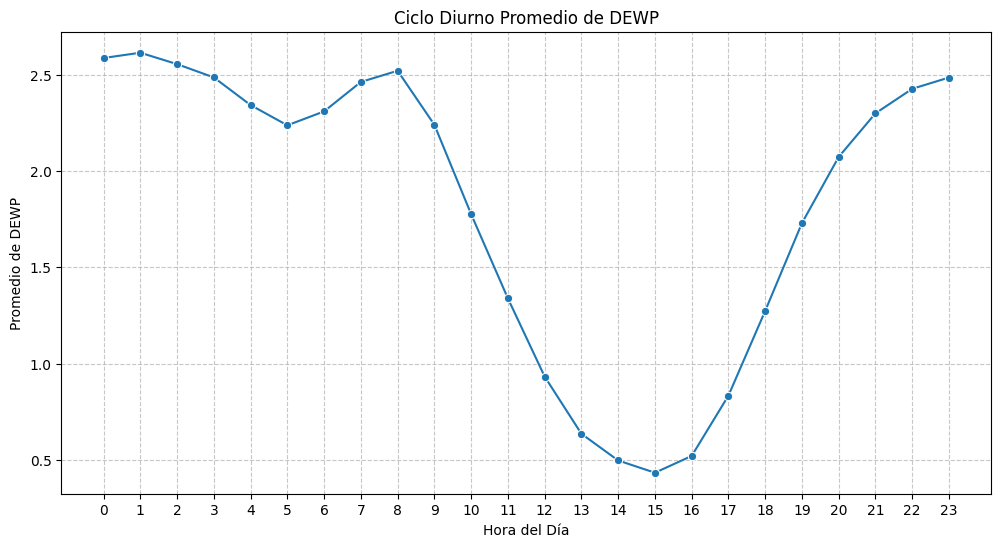

In [ ]:
# --- Seleccione la variable que desea visualizar --- #
variable_seleccionada = "Iws" # @param ["pm2.5","DEWP","TEMP","PRES","Iws","Ir","Is"]

# Asegurarse de que la columna 'hour' sea numérica para agrupar
# (Aunque ya está en el df, es una buena práctica asegurar el tipo)
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

# Calcular el promedio de la variable seleccionada para cada hora del día
ciclo_diurno = df.groupby('hour')[variable_seleccionada].mean().reset_index()

# Crear el gráfico del ciclo diurno
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y=variable_seleccionada, data=ciclo_diurno, marker='o')
plt.title(f'Ciclo Diurno Promedio de {variable_seleccionada.upper()}')
plt.xlabel('Hora del Día')
plt.ylabel(f'Promedio de {variable_seleccionada.upper()}')
plt.xticks(range(0, 24)) # Mostrar todas las horas en el eje X
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# --- Creación de df_working y normalización de la variable seleccionada por su ciclo diurno ---

# Aseguramos que 'variable_seleccionada' esté definida. (Actualmente 'DEWP')
variable_seleccionada = "TEMP" # @param ["pm2.5","DEWP","TEMP","PRES","Iws","Ir","Is"]

# Crear un DataFrame de trabajo con 'date' como índice y 'hour' como columna
df_working = df.copy()
df_working['date'] = df_dates
df_working = df_working.set_index('date')
df_working['hour'] = df_working.index.hour

# Normalizar la variable seleccionada por su ciclo diurno
hourly_mean_series = df_working.groupby('hour')[variable_seleccionada].transform('mean')
hourly_std_series = df_working.groupby('hour')[variable_seleccionada].transform('std')

# Manejar casos donde la desviación estándar es 0 o NaN
normalized_selected_series = (df_working[variable_seleccionada] - hourly_mean_series)
# Para horas donde std es 0, establecer el valor normalizado en NaN
normalized_selected_series[hourly_std_series != 0] = normalized_selected_series[hourly_std_series != 0] / hourly_std_series[hourly_std_series != 0]
normalized_selected_series[hourly_std_series == 0] = np.nan

normalized_selected_series = normalized_selected_series.dropna()

print(f"La serie '{variable_seleccionada}' normalizada por ciclo diurno ('normalized_selected_series') ha sido creada.")
display(normalized_selected_series.head())

La serie 'TEMP' normalizada por ciclo diurno ('normalized_selected_series') ha sido creada.


,TEMP
date,
2010-01-01 00:00:00,-1.829966
2010-01-01 01:00:00,-1.875172
2010-01-01 02:00:00,-1.753227
2010-01-01 03:00:00,-1.982439
2010-01-01 04:00:00,-1.782555


In [ ]:
# --- Normalizar la serie pm2.5 por su ciclo diurno ---

# pm2.5_series ya tiene el índice de fecha adecuado y sin NaNs
# df_working_pm25 se crea para asegurar que tenemos el 'hour' correcto para pm2.5
df_working_pm25 = df.copy() # Hacer una copia para evitar modificar el dataframe original directamente
df_working_pm25['date'] = df_dates
df_working_pm25 = df_working_pm25.set_index('date')
df_working_pm25['hour'] = df_working_pm25.index.hour

# Calcular la media y desviación estándar horaria para pm2.5
hourly_mean_pm25 = df_working_pm25.groupby('hour')['pm2.5'].transform('mean')
hourly_std_pm25 = df_working_pm25.groupby('hour')['pm2.5'].transform('std')

# Normalizar pm2.5
normalized_pm25_series = (df_working_pm25['pm2.5'] - hourly_mean_pm25)

# Manejar casos donde la desviación estándar es 0 o NaN para pm2.5
# Solo dividir si la desviación estándar no es cero para evitar ZeroDivisionError
normalized_pm25_series[hourly_std_pm25 != 0] = normalized_pm25_series[hourly_std_pm25 != 0] / hourly_std_pm25[hourly_std_pm25 != 0]
normalized_pm25_series[hourly_std_pm25 == 0] = np.nan # Establecer como NaN si la desviación estándar es cero

normalized_pm25_series = normalized_pm25_series.dropna()

print("La serie 'pm2.5' normalizada por ciclo diurno ('normalized_pm25_series') ha sido creada.")
display(normalized_pm25_series.head())

La serie 'pm2.5' normalizada por ciclo diurno ('normalized_pm25_series') ha sido creada.


,pm2.5
date,
2010-01-02 00:00:00,0.151217
2010-01-02 01:00:00,0.321463
2010-01-02 02:00:00,0.484160
2010-01-02 03:00:00,0.747995
2010-01-02 04:00:00,0.358187


In [ ]:
import pandas as pd
import numpy as np

# --- Configuración de lags para correlación cruzada ---
# Lags para la variable seleccionada (X_t-lag en la fórmula Corr(Y_t, X_t-lag))
max_lag_for_selected_var = 100
# Solo necesitamos la correlación en el tiempo t (lead=0) para pm2.5 (Y_t)
max_lead_for_pm25 = 0

# --- Alineación de las series ---
# Asegurar que ambas series tienen un índice de tipo DatetimeIndex
pm25_series_to_use = normalized_pm25_series.copy() # Usar la serie pm2.5 normalizada
normalized_selected_series_dt = normalized_selected_series.copy()

# Encontrar el índice común para alinear ambas series
common_index_ccf = pm25_series_to_use.index.intersection(normalized_selected_series_dt.index)

pm25_aligned_ccf = pm25_series_to_use.loc[common_index_ccf]
normalized_selected_aligned_ccf = normalized_selected_series_dt.loc[common_index_ccf]

# --- Preparar DataFrame con valores rezagados (lagged) y adelantados (leaded) ---
data_ccf = {}

# pm2.5 (variable objetivo) sin adelanto, ya que buscamos Y_t
for lead in range(0, max_lead_for_pm25 + 1):
    data_ccf[f"pm2.5_norm_t+{lead}"] = pm25_aligned_ccf.shift(-lead)

# Variable seleccionada normalizada con lags, para X_t-lag
for lag in range(0, max_lag_for_selected_var + 1):
    data_ccf[f"{variable_seleccionada}_norm_t-{lag}"] = normalized_selected_aligned_ccf.shift(lag)

X_ccf = pd.DataFrame(data_ccf, index=common_index_ccf)

# --- Cálculo de la correlación con múltiples métodos ---
correlation_methods = ['pearson', 'spearman', 'kendall']
min_samples_ccf = 24 * 365 # Mínimo de 1 año de datos horarios para calcular la correlación

# Etiquetas para las filas (pm2.5_t+0) y columnas (variable_seleccionada_norm_t-lag)
row_labels_ccf = [f"pm2.5_norm_t+{lead}" for lead in range(0, max_lead_for_pm25 + 1)]
col_labels_ccf = [f"{variable_seleccionada}_norm_t-{lag}" for lag in range(0, max_lag_for_selected_var + 1)]

corr_matrices = {}
ccf_df_all_methods = pd.DataFrame(columns=['method', 'lag', 'cross_correlation'])

for method in correlation_methods:
    corr_mat_current_method = pd.DataFrame(
        index=row_labels_ccf,
        columns=col_labels_ccf,
        dtype=float
    )
    for lead_idx in range(0, max_lead_for_pm25 + 1):
        y_ccf = X_ccf[f"pm2.5_norm_t+{lead_idx}"]
        for lag_idx in range(0, max_lag_for_selected_var + 1):
            x_ccf = X_ccf[f"{variable_seleccionada}_norm_t-{lag_idx}"]
            tmp_ccf = pd.concat([x_ccf, y_ccf], axis=1).dropna()

            if len(tmp_ccf) >= min_samples_ccf:
                corr_val = tmp_ccf.iloc[:, 0].corr(tmp_ccf.iloc[:, 1], method=method)
                corr_mat_current_method.loc[f"pm2.5_norm_t+{lead_idx}", f"{variable_seleccionada}_norm_t-{lag_idx}"] = corr_val
            else:
                corr_mat_current_method.loc[f"pm2.5_norm_t+{lead_idx}", f"{variable_seleccionada}_norm_t-{lag_idx}"] = np.nan
    corr_matrices[method] = corr_mat_current_method

    print(f"Matriz de correlación {method.capitalize()} entre pm2.5_norm (en tiempo t) y {variable_seleccionada}_norm (en tiempo t-lag):")
    display(corr_mat_current_method)

    # Si solo se calculó un 'lead' (pm2.5_norm_t+0), extraemos la fila como resultado final
    if max_lead_for_pm25 == 0:
        cross_correlation_results = corr_mat_current_method.loc['pm2.5_norm_t+0']
        ccf_df_current_method = pd.DataFrame({
            'lag': range(0, max_lag_for_selected_var + 1),
            'cross_correlation': cross_correlation_results.values,
            'method': method.capitalize()
        })
        ccf_df_all_methods = pd.concat([ccf_df_all_methods, ccf_df_current_method], ignore_index=True)
        print(f"Correlación cruzada {method.capitalize()} para {variable_seleccionada}_norm y pm2.5_norm (en lag cero y lags positivos):")
        display(ccf_df_current_method.head())
        display(ccf_df_current_method.tail())

print("\nDataFrame combinado de resultados de correlación cruzada para todos los métodos ('ccf_df_all_methods'):")
display(ccf_df_all_methods.head())
display(ccf_df_all_methods.tail())

Matriz de correlación Pearson entre pm2.5_norm (en tiempo t) y TEMP_norm (en tiempo t-lag):


,TEMP_norm_t-0,TEMP_norm_t-1,TEMP_norm_t-2,TEMP_norm_t-3,TEMP_norm_t-4,TEMP_norm_t-5,TEMP_norm_t-6,TEMP_norm_t-7,TEMP_norm_t-8,TEMP_norm_t-9,...,TEMP_norm_t-91,TEMP_norm_t-92,TEMP_norm_t-93,TEMP_norm_t-94,TEMP_norm_t-95,TEMP_norm_t-96,TEMP_norm_t-97,TEMP_norm_t-98,TEMP_norm_t-99,TEMP_norm_t-100
pm2.5_norm_t+0,-0.069358,-0.072401,-0.074007,-0.074148,-0.073441,-0.072196,-0.070928,-0.069734,-0.068865,-0.068293,...,-0.104034,-0.103999,-0.104054,-0.10398,-0.103811,-0.103602,-0.103307,-0.10311,-0.10286,-0.102777


Correlación cruzada Pearson para TEMP_norm y pm2.5_norm (en lag cero y lags positivos):


/tmp/ipykernel_4060/3805631872.py:75: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,lag,cross_correlation,method
0,0,-0.069358,Pearson
1,1,-0.072401,Pearson
2,2,-0.074007,Pearson
3,3,-0.074148,Pearson
4,4,-0.073441,Pearson


...

,lag,cross_correlation,method
0,0,0.023385,Kendall
1,1,0.021026,Kendall
2,2,0.019623,Kendall
3,3,0.019383,Kendall
4,4,0.019899,Kendall


,lag,cross_correlation,method
96,96,-0.001399,Kendall
97,97,-0.001270,Kendall
98,98,-0.001026,Kendall
99,99,-0.000685,Kendall
100,100,-0.000397,Kendall



DataFrame combinado de resultados de correlación cruzada para todos los métodos ('ccf_df_all_methods'):


,method,lag,cross_correlation
0,Pearson,0,-0.069358
1,Pearson,1,-0.072401
2,Pearson,2,-0.074007
3,Pearson,3,-0.074148
4,Pearson,4,-0.073441


,method,lag,cross_correlation
298,Kendall,96,-0.001399
299,Kendall,97,-0.001270
300,Kendall,98,-0.001026
301,Kendall,99,-0.000685
302,Kendall,100,-0.000397


### Correlación Cruzada entre una Variable Normalizada por Ciclo Diurno y pm2.5

In [ ]:
import plotly.express as px

# Asegúrate de que ccf_df_all_methods esté disponible y contenga la columna 'method'
# Plotly Express puede graficar fácilmente múltiples grupos
fig = px.line(ccf_df_all_methods,
              x='lag',
              y='cross_correlation',
              color='method', # Usar el método como color para diferenciar las líneas
              title=f'Correlación Cruzada entre pm2.5 (Normalizado Diariamente) y {variable_seleccionada.upper()} (Normalizado Diariamente) por Método',
              labels={'lag': f'Lag de {variable_seleccionada.upper()} (horas atrás)',
                      'cross_correlation': 'Correlación',
                      'method': 'Método de Correlación'})

fig.add_hline(y=0, line_dash="dash", line_color="gray", annotation_text="Cero Correlación", annotation_position="bottom right")

# Puedes añadir límites de confianza si se calculan para todos los métodos y se incluyen en ccf_df_all_methods
# Por simplicidad, los dejaremos fuera por ahora o se añadirían como líneas separadas si fueran constantes para todos los métodos.
# conf_interval = 1.96 / np.sqrt(len(pm25_aligned_ccf)) # Asumiendo N_observations constante
# fig.add_hline(y=conf_interval, line_dash="dot", line_color="red", annotation_text="Límite de Confianza (95%)")
# fig.add_hline(y=-conf_interval, line_dash="dot", line_color="red")

fig.update_layout(hovermode="x unified") # Mejora la interactividad al pasar el ratón
fig.show()